In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import keras_cv

In [3]:
import os
import pickle
from sklearn.preprocessing import LabelEncoder

# --- Create the 'models' directory if it doesn't exist ---
os.makedirs("../models/", exist_ok=True)

# --- Path to your raw data (used to get the class names) ---
plant_path = "../data/raw/PlantVillage/"

# Get a sorted list of folder names (our classes)
class_names = sorted([folder for folder in os.listdir(plant_path) 
                      if os.path.isdir(os.path.join(plant_path, folder))])

# Create and fit the LabelEncoder
le = LabelEncoder()
le.fit(class_names)

# --- Save the LabelEncoder to the file ---
print(f"Saving label encoder to ../models/label_encoder.pkl")
with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("File saved successfully.")

Saving label encoder to ../models/label_encoder.pkl
File saved successfully.


In [4]:
# --- Load Data ---
print("Loading processed PlantVillage (RGB) data...")
X_train_rgb = np.load("../data/processed/X_train_rgb.npy")
y_train_rgb = np.load("../data/processed/y_train_rgb.npy")
X_test_rgb = np.load("../data/processed/X_test_rgb.npy")
y_test_rgb = np.load("../data/processed/y_test_rgb.npy")

print(f"X_train_rgb shape: {X_train_rgb.shape}")
print(f"y_train_rgb shape: {y_train_rgb.shape}")

# --- Load Label Encoder ---
print("Loading label encoder...")
with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

class_names = le.classes_
NUM_CLASSES = len(class_names)

print(f"Data loaded. Found {NUM_CLASSES} classes:")
print(class_names)

Loading processed PlantVillage (RGB) data...
X_train_rgb shape: (16318, 128, 128, 3)
y_train_rgb shape: (16318,)
Loading label encoder...
Data loaded. Found 16 classes:
['.ipynb_checkpoints' 'Pepper__bell___Bacterial_spot'
 'Pepper__bell___healthy' 'Potato___Early_blight' 'Potato___Late_blight'
 'Potato___healthy' 'Tomato_Bacterial_spot' 'Tomato_Early_blight'
 'Tomato_Late_blight' 'Tomato_Leaf_Mold' 'Tomato_Septoria_leaf_spot'
 'Tomato_Spider_mites_Two_spotted_spider_mite' 'Tomato__Target_Spot'
 'Tomato__Tomato_YellowLeaf__Curl_Virus' 'Tomato__Tomato_mosaic_virus'
 'Tomato_healthy']


In [5]:
datagen = ImageDataGenerator(
    rotation_range=20,       # randomly rotate images
    width_shift_range=0.1,   # randomly shift images horizontally
    height_shift_range=0.1,  # randomly shift images vertically
    shear_range=0.1,         # shear transformations
    zoom_range=0.1,          # randomly zoom in
    horizontal_flip=True,    # randomly flip images horizontally
    fill_mode='nearest'      # fill in new pixels
)

datagen.fit(X_train_rgb)

In [6]:
# Stop training if 'val_loss' doesn't improve for 3 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Reduce learning rate if 'val_loss' plateaus for 2 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

callbacks = [early_stopping, reduce_lr]

# Custom CNN

In [7]:
def build_custom_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

# Build and train the CNN
cnn_model = build_custom_cnn((128, 128, 3), NUM_CLASSES)
print(cnn_model.summary())

history_cnn = cnn_model.fit(
    datagen.flow(X_train_rgb, y_train_rgb, batch_size=32),
    epochs=20, # Train for longer, EarlyStopping will handle it
    validation_data=(X_test_rgb, y_test_rgb),
    callbacks=callbacks
)

C:\Users\DELL\Mini Project\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           2,064 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,824 (436.81 KB)

 Trainable params: 111,824 (436.81 KB)

 Non-trainable params: 0 (0.00 B)

None


C:\Users\DELL\Mini Project\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 97s 186ms/step - accuracy: 0.2697 - loss: 2.2497 - val_accuracy: 0.4039 - val_loss: 1.8608 - learning_rate: 0.0010
Epoch 2/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 94s 184ms/step - accuracy: 0.4583 - loss: 1.6803 - val_accuracy: 0.5985 - val_loss: 1.2649 - learning_rate: 0.0010
Epoch 3/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 96s 188ms/step - accuracy: 0.5844 - loss: 1.2815 - val_accuracy: 0.7103 - val_loss: 0.8706 - learning_rate: 0.0010
Epoch 4/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 100s 196ms/step - accuracy: 0.6469 - loss: 1.0574 - val_accuracy: 0.7331 - val_loss: 0.8072 - learning_rate: 0.0010
Epoch 5/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 95s 185ms/step - accuracy: 0.6778 - loss: 0.9532 - val_accuracy: 0.7252 - val_loss: 0.7991 - learning_rate: 0.0010
Epoch 6/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 93s 182ms/step - accuracy: 0.7043 - loss: 0.8803 - val_accuracy: 0.7314 - val_loss: 0.7990 - learning_rate: 0.0010
Epoch 7/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 97s 189ms/step - accuracy: 0.

# VGG16

In [20]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# Load pre-trained VGG16 base
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
vgg_base.trainable = False # Freeze the base

# Build the model
vgg_model = models.Sequential([
    # Define the input shape for the whole model
    layers.Input(shape=(128, 128, 3)),
    
    # THIS IS THE FIX:
    # 1. Convert our [0, 1] data back to [0, 255]
    layers.Rescaling(255.0),
    # 2. NOW apply the VGG-specific preprocessing
    layers.Lambda(vgg_preprocess),
    
    # Now the data is in the correct format for the vgg_base
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Use a slower learning rate for transfer learning
vgg_model.compile(optimizer=Adam(learning_rate=1e-4), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

print(vgg_model.summary())

history_vgg = vgg_model.fit(
    datagen.flow(X_train_rgb, y_train_rgb, batch_size=32),
    epochs=20, 
    validation_data=(X_test_rgb, y_test_rgb),
    callbacks=callbacks
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 16)                  │           4,112 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,850,128 (56.65 MB)

 Trainable params: 135,440 (529.06 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 971s 2s/step - accuracy: 0.2685 - loss: 3.8476 - val_accuracy: 0.5551 - val_loss: 1.4418 - learning_rate: 1.0000e-04
Epoch 2/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.4467 - loss: 1.8292
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
510/510 ━━━━━━━━━━━━━━━━━━━━ 602s 1s/step - accuracy: 0.4754 - loss: 1.7078 - val_accuracy: 0.6706 - val_loss: 1.0760 - learning_rate: 1.0000e-04
Epoch 3/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 615s 1s/step - accuracy: 0.5449 - loss: 1.4443 - val_accuracy: 0.6833 - val_loss: 1.0237 - learning_rate: 2.0000e-05
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


# ResNet50

In [21]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Load pre-trained ResNet50 base
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
resnet_base.trainable = False # Freeze the base

# Build the model
resnet_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    
    # THIS IS THE FIX:
    # 1. Convert [0, 1] -> [0, 255]
    layers.Rescaling(255.0),
    # 2. Apply ResNet-specific preprocessing
    layers.Lambda(resnet_preprocess),
    
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Use a slower learning rate
resnet_model.compile(optimizer=Adam(learning_rate=1e-4), 
                     loss='sparse_categorical_crossentropy', 
                     metrics=['accuracy'])

print(resnet_model.summary())

history_resnet = resnet_model.fit(
    datagen.flow(X_train_rgb, y_train_rgb, batch_size=32),
    epochs=20,
    validation_data=(X_test_rgb, y_test_rgb),
    callbacks=callbacks
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_2 (Lambda)                    │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 4, 4, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_5           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 16)                  │           4,112 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,116,368 (92.00 MB)

 Trainable params: 528,656 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None
Epoch 1/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 287s 553ms/step - accuracy: 0.5761 - loss: 1.3912 - val_accuracy: 0.8044 - val_loss: 0.6541 - learning_rate: 1.0000e-04
Epoch 2/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7517 - loss: 0.7764
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
510/510 ━━━━━━━━━━━━━━━━━━━━ 271s 532ms/step - accuracy: 0.7709 - loss: 0.7189 - val_accuracy: 0.8458 - val_loss: 0.4916 - learning_rate: 1.0000e-04
Epoch 3/20
510/510 ━━━━━━━━━━━━━━━━━━━━ 287s 563ms/step - accuracy: 0.8167 - loss: 0.5744 - val_accuracy: 0.8659 - val_loss: 0.4370 - learning_rate: 2.0000e-05
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.



--- MODEL EVALUATION ---

--- Results for Custom CNN ---


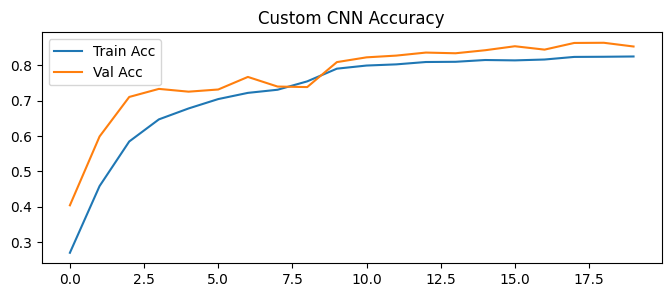

128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step
Classification Report for Custom CNN:
                                             precision    recall  f1-score   support

                         .ipynb_checkpoints       0.82      0.79      0.81       199
              Pepper__bell___Bacterial_spot       0.82      0.97      0.89       296
                     Pepper__bell___healthy       0.93      0.93      0.93       200
                      Potato___Early_blight       0.87      0.68      0.76       200
                       Potato___Late_blight       0.65      0.43      0.52        30
                           Potato___healthy       0.94      0.88      0.91       426
                      Tomato_Bacterial_spot       0.68      0.70      0.69       200
                        Tomato_Early_blight       0.85      0.76      0.80       382
                         Tomato_Late_blight       0.94      0.86      0.90       190
                           Tomato_Leaf_Mold       0.88      0.79     

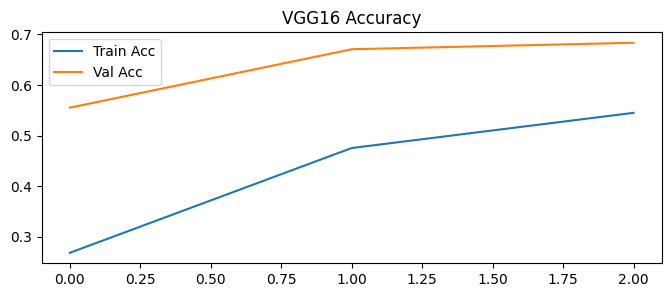

128/128 ━━━━━━━━━━━━━━━━━━━━ 109s 847ms/step
Classification Report for VGG16:
                                             precision    recall  f1-score   support

                         .ipynb_checkpoints       0.59      0.60      0.59       199
              Pepper__bell___Bacterial_spot       0.75      0.89      0.81       296
                     Pepper__bell___healthy       0.71      0.69      0.70       200
                      Potato___Early_blight       0.52      0.42      0.47       200
                       Potato___Late_blight       0.00      0.00      0.00        30
                           Potato___healthy       0.56      0.66      0.61       426
                      Tomato_Bacterial_spot       0.26      0.12      0.16       200
                        Tomato_Early_blight       0.62      0.59      0.60       382
                         Tomato_Late_blight       0.30      0.31      0.30       190
                           Tomato_Leaf_Mold       0.38      0.47      0

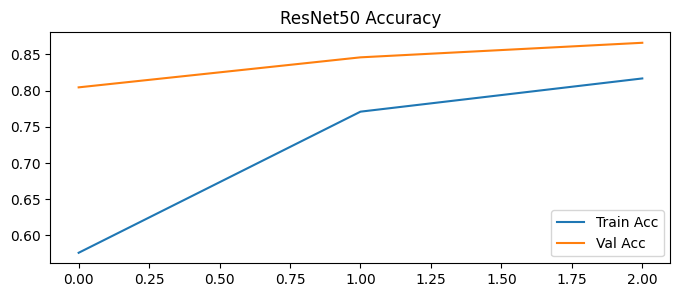

128/128 ━━━━━━━━━━━━━━━━━━━━ 51s 388ms/step


Classification Report for ResNet50:
                                             precision    recall  f1-score   support

                         .ipynb_checkpoints       0.76      0.87      0.81       199
              Pepper__bell___Bacterial_spot       0.88      0.97      0.92       296
                     Pepper__bell___healthy       0.93      0.94      0.94       200
                      Potato___Early_blight       0.86      0.88      0.87       200
                       Potato___Late_blight       0.78      0.47      0.58        30
                           Potato___healthy       0.79      0.86      0.82       426
                      Tomato_Bacterial_spot       0.73      0.22      0.34       200
                        Tomato_Early_blight       0.77      0.80      0.78       382
                         Tomato_Late_blight       0.78      0.68      0.73       190
                           Tomato_Leaf_Mold       0.74      0.77      0.75       354
                  Tomato_Sep

In [24]:
# --- Store all models and histories for easy comparison ---
# We are comparing only the models we trained
all_models = {
    "Custom CNN": (cnn_model, history_cnn),
    "VGG16": (vgg_model, history_vgg),
    "ResNet50": (resnet_model, history_resnet)
}

results = []

print("\n--- MODEL EVALUATION ---")

# --- Loop through each model to plot history and get reports ---
for name, (model, history) in all_models.items():
    print(f"\n--- Results for {name} ---")
    
    # 1. Plot Training History
    plt.figure(figsize=(8, 3))
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{name} Accuracy')
    plt.legend()
    plt.show()

    # 2. Get predictions on test set
    y_pred_probs = model.predict(X_test_rgb)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # 3. Print Classification Report
    print(f"Classification Report for {name}:")
    
    # --- THIS IS THE FIX ---
    # We add 'labels=np.arange(NUM_CLASSES)' to tell the function
    # to report on all 16 classes (0-15), even if one is missing.
    print(classification_report(y_test_rgb, y_pred, target_names=class_names, labels=np.arange(NUM_CLASSES), zero_division=0))
    # ---
    
    # 4. Save the best validation accuracy
    val_acc = max(history.history['val_accuracy'])
    results.append({
        "Model": name,
        "Best Validation Accuracy": val_acc
    })

# --- Final Comparison Table ---
print("\n--- FINAL MODEL COMPARISON ---")
df_results = pd.DataFrame(results).sort_values(by="Best Validation Accuracy", ascending=False)
df_results['Best Validation Accuracy'] = (df_results['Best Validation Accuracy'] * 100).round(2)
print(df_results)

# --- Save the best model ---
# This will automatically find the best model from your results
best_model_name = df_results.iloc[0]['Model']
best_model_obj = all_models[best_model_name][0]

print(f"\nSaving the best model ({best_model_name}) to '../models/plant_disease_rgb_model.h5'")
best_model_obj.save("../models/plant_disease_rgb_model.h5")
print("Model saved.")